In [1]:
# 步骤1：环境准备
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import mplfinance as mpf # k线图
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体显示
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # macos
# plt.rcParams['font.sans-serif'] = ['SimHei']  # windows
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 步骤2：参数设置
symbol = 'AAPL'        # 股票代码
period = '1y'          # 时间周期
ma1_period = 10         # MA周期
ma2_period = 20         # MA周期

In [3]:
# 步骤3：获取股票数据
ticker = yf.Ticker(symbol)
df = ticker.history(period=period)
print(f"✅ 数据获取完成，共 {len(df)} 个交易日")

✅ 数据获取完成，共 251 个交易日


In [5]:
# 步骤4：计算 OBV
df['OBV'] = np.sign(df['Close'].diff()) * df['Volume']
df['OBV'] = df['OBV'].fillna(0).cumsum()
df['OBV_MA'] = df['OBV'].rolling(ma1_period).mean()

print('✅OBV 计算完成')

✅OBV 计算完成


In [6]:
# 步骤5：计算 Volume_MA
df['Volume_MA1'] = df['Volume'].rolling(ma1_period).mean()
df['Volume_MA2'] = df['Volume'].rolling(ma2_period).mean()

print('✅Volume 计算完成')

✅Volume 计算完成


In [10]:
# 步骤6：统计趋势
print("📊 OBV 历史统计")
print("=" * 50)
obv_change = df['OBV'].diff().dropna()
obv_up_days = (obv_change > 0).sum()
obv_down_days = (obv_change < 0).sum()

print(f"上涨天数：{obv_up_days}")
print(f"下跌天数：{obv_down_days}")
print(f"上升比例：{obv_up_days / len(obv_change) * 100:.2f}%")
print(f"最近OBV变化：{obv_change.iloc[-1]:.2f}")

print("\n📊 Volume 历史统计")
print("=" * 50)
volume_mean = df['Volume'].mean()
volume_std = df['Volume'].std()
volume_latest = df['Volume'].iloc[-1]
volume_ratio = volume_latest / volume_mean

print(f"成交量均值：{volume_mean:.0f}")
print(f"成交量标准差：{volume_std:.0f}")
print(f"当前成交量：{volume_latest:.0f}")
print(f"量能倍数：{volume_ratio:.2f}倍")

📊 OBV 历史统计
上涨天数：134
下跌天数：115
上升比例：53.60%
最近OBV变化：13587999.00

📊 Volume 历史统计
成交量均值：53659964
成交量标准差：23427494
当前成交量：13587999
量能倍数：0.25倍


In [11]:
# 步骤7：当前趋势判断
if df['OBV'].iloc[-1] > df['OBV_MA'].iloc[-1]:
    trend = "资金流入（OBV位于均线上方）"
elif df['OBV'].iloc[-1] < df['OBV_MA'].iloc[-1]:
    trend = "资金流出（OBV位于均线下方）"
else:
    trend = "资金流向平稳"

print("\n📈 当前趋势判断")
print("=" * 50)
print(f"当前资金趋势：{trend}")

# Volume趋势判断
print(f"\n📊 成交量趋势判断")
print("=" * 50)
if volume_ratio > 1.5:
    volume_signal = "放量突破"
elif volume_ratio > 1.2:
    volume_signal = "温和放量"
elif volume_ratio < 0.7:
    volume_signal = "缩量整理"
else:
    volume_signal = "量能正常"

print(f"成交量信号：{volume_signal}")

# 综合判断
if trend == "资金流入（OBV位于均线上方）" and volume_ratio > 1.2:
    print("\n🎯 综合信号：强势上涨")
elif trend == "资金流出（OBV位于均线下方）" and volume_ratio > 1.2:
    print("\n🎯 综合信号：放量下跌")
elif trend == "资金流入（OBV位于均线上方）" and volume_ratio < 0.7:
    print("\n🎯 综合信号：缩量上涨（谨慎）")
else:
    print("\n🎯 综合信号：观望等待")


📈 当前趋势判断
当前资金趋势：资金流入（OBV位于均线上方）

📊 成交量趋势判断
成交量信号：缩量整理

🎯 综合信号：缩量上涨（谨慎）


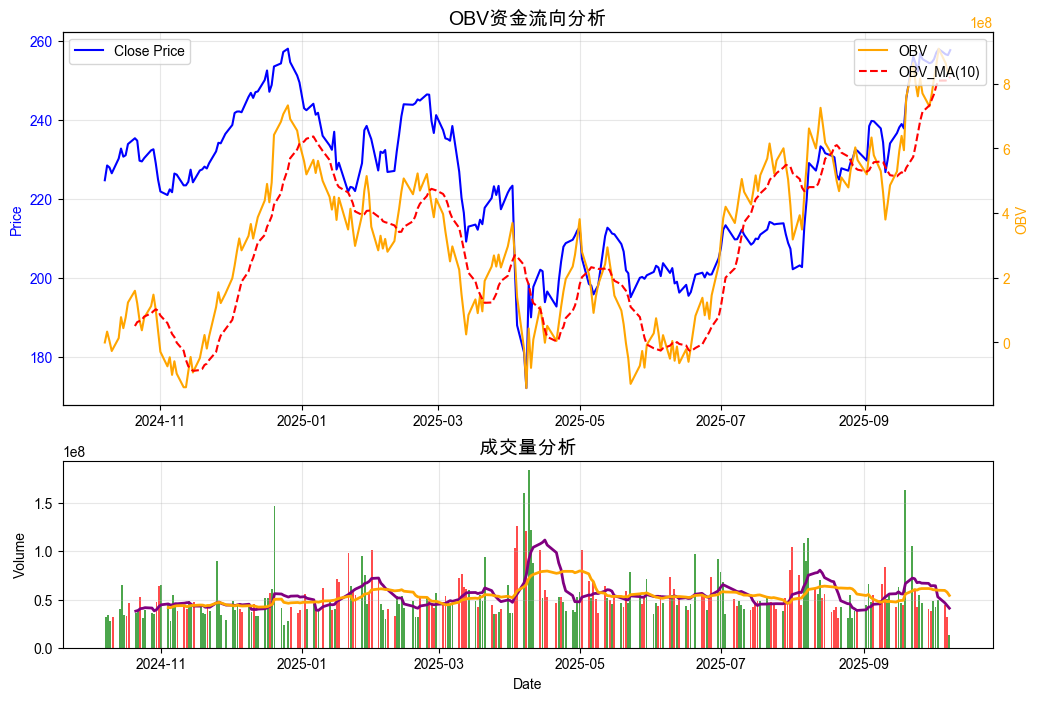

In [12]:
# 步骤8：可视化
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), height_ratios=[2, 1])

# 上图：价格和OBV分析
ax1.plot(df['Close'], color='blue', label='Close Price', linewidth=1.5)
ax1.set_ylabel('Price', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax1_obv = ax1.twinx()
ax1_obv.plot(df['OBV'], color='orange', label='OBV', linewidth=1.5)
ax1_obv.plot(df['OBV_MA'], color='red', linestyle='--', label='OBV_MA(10)')
ax1_obv.set_ylabel('OBV', color='orange')
ax1_obv.tick_params(axis='y', labelcolor='orange')

ax1.set_title("OBV资金流向分析", fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')
ax1_obv.legend(loc='upper right')
ax1.grid(alpha=0.3)

# 下图：成交量分析
ax2.bar(df.index, df['Volume'], color=['red' if close < open else 'green' 
                                       for close, open in zip(df['Close'], df['Open'])], 
        alpha=0.7, width=0.8)
ax2.set_ylabel('Volume', color='black')
ax2.set_xlabel('Date')
ax2.set_title("成交量分析", fontsize=14, fontweight='bold')
ax2.grid(alpha=0.3)

# 添加成交量移动平均线
ax2.plot(df.index, df['Volume_MA1'], color='purple', linewidth=2, label='Volume_MA1')
ax2.plot(df.index, df['Volume_MA2'], color='orange', linewidth=2, label='Volume_MA2')